# Evaluate Transformer checkpoints

This notebook lets you interactively evaluate language model checkpoints in `llm_backbone/checkpoints` on cross-entropy loss and perplexity, and visualize the results.

In [1]:
from __future__ import annotations

from dataclasses import asdict
from pathlib import Path
from typing import Any, Dict, List, Optional

import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml

import llm_backbone.Transformers_cs336 as my_tf

torch.set_float32_matmul_precision('medium')

def detect_device() -> str:
    if torch.cuda.is_available():
        return 'cuda'
    if getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available():
        return 'mps'
    return 'cpu'

def load_config(path: Path) -> Dict[str, Any]:
    print(f'Loading config from: {path}')
    with path.open('r') as handle:
        return yaml.safe_load(handle)

def build_model(config: Dict[str, Any], device: str) -> torch.nn.Module:
    print('Building Transformer model from config...')
    model_cfg = config['model']
    model = my_tf.transformer.Transformer(
        d_model=model_cfg['d_model'],
        num_heads=model_cfg['num_heads'],
        d_ff=model_cfg['d_ff'],
        vocab_size=model_cfg['vocab_size'],
        context_length=model_cfg['context_length'],
        num_layers=model_cfg['num_layers'],
        max_seq_len=model_cfg['context_length'],
        theta=model_cfg['rope_theta'],
        device=device,
    )
    model.to(device)
    model.eval()
    return model

def load_memmap(path: Path) -> np.memmap:
    print(f'Loading memmapped dataset from: {path}')
    return np.memmap(path, dtype=np.uint16, mode='r')

def evaluate_on_split(
    model: torch.nn.Module,
    dataset: np.memmap,
    config: Dict[str, Any],
    device: str,
    num_batches: int,
    batch_size: int,
) -> Dict[str, float]:
    context_length = config['model']['context_length']
    losses: List[float] = []
    perplexities: List[float] = []

    model.eval()
    print(f'Evaluating over {num_batches} batches (batch_size={batch_size})...')
    with torch.no_grad():
        for batch_idx in range(num_batches):
            input_ids, target_ids = my_tf.modules.get_batch(
                dataset=dataset,
                batch_size=batch_size,
                context_length=context_length,
                device=device,
            )
            logits = model(input_ids)
            logits_flat = logits.view(-1, logits.size(-1))
            targets_flat = target_ids.reshape(-1)
            loss_tensor = my_tf.modules.get_cross_entropy_loss(logits_flat, targets_flat)
            ppl_tensor = torch.exp(loss_tensor)
            losses.append(float(loss_tensor.item()))
            perplexities.append(float(ppl_tensor.item()))
            if (batch_idx + 1) % max(1, num_batches // 5) == 0:
                print(f'  batch {batch_idx + 1}/{num_batches} done')

    return {
        'loss': float(np.mean(losses)),
        'perplexity': float(np.mean(perplexities)),
    }

def load_checkpoint_into_model(
    model: torch.nn.Module,
    checkpoint_path: Path,
    device: str,
) -> Optional[int]:
    print(f'Loading checkpoint: {checkpoint_path}')
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    state_dict = checkpoint.get('model_state_dict', checkpoint)

    model_state = model.state_dict()
    if set(state_dict.keys()) != set(model_state.keys()):
        stripped_state: Dict[str, Any] = {}
        for key, value in state_dict.items():
            if key.startswith('module.'):
                stripped_state[key[len('module.'):]] = value
            else:
                stripped_state[key] = value
        state_dict = stripped_state

    incompatible = model.load_state_dict(state_dict, strict=False)
    if incompatible.missing_keys or incompatible.unexpected_keys:
        print(f'[warn] Incompatible keys for {checkpoint_path.name}: {asdict(incompatible)}')

    model.to(device)
    model.eval()
    return checkpoint.get('iteration')

def find_checkpoints(checkpoints_dir: Path) -> List[Path]:
    checkpoint_paths = sorted(checkpoints_dir.glob('*.pt'))
    print(f'Found {len(checkpoint_paths)} checkpoint(s) under {checkpoints_dir}')
    return checkpoint_paths

def plot_metrics(
    results: List[Dict[str, Any]],
    split: str,
) -> None:
    if not results:
        print('No results to plot.')
        return

    sorted_results = sorted(
        results,
        key=lambda entry: (
            entry.get('iteration') if entry.get('iteration') is not None else float('inf'),
            entry['name'],
        ),
    )

    x_values: List[float] = []
    labels: List[str] = []
    losses: List[float] = []
    perplexities: List[float] = []

    for index, entry in enumerate(sorted_results):
        iteration = entry.get('iteration')
        x_values.append(float(iteration) if iteration is not None else float(index))
        labels.append(entry['name'])
        losses.append(entry[f'{split}_loss'])
        perplexities.append(entry[f'{split}_perplexity'])

    fig, ax_loss = plt.subplots(figsize=(8, 5))
    ax_ppl = ax_loss.twinx()

    ax_loss.plot(x_values, losses, marker='o', color='tab:blue', label=f'{split} loss')
    ax_ppl.plot(x_values, perplexities, marker='s', color='tab:orange', label=f'{split} perplexity')

    ax_loss.set_xlabel('iteration (or index)')
    ax_loss.set_ylabel('cross-entropy loss', color='tab:blue')
    ax_ppl.set_ylabel('perplexity', color='tab:orange')

    ax_loss.tick_params(axis='y', labelcolor='tab:blue')
    ax_ppl.tick_params(axis='y', labelcolor='tab:orange')

    fig.suptitle(f'Checkpoint {split} metrics')
    fig.tight_layout()
    plt.show()

    fig_bar, ax_bar = plt.subplots(figsize=(10, 4))
    positions = np.arange(len(sorted_results))
    ax_bar.bar(positions, perplexities, color='tab:orange')
    ax_bar.set_xticks(positions)
    ax_bar.set_xticklabels(labels, rotation=45, ha='right')
    ax_bar.set_ylabel(f'{split} perplexity')
    ax_bar.set_title(f'Checkpoint {split} perplexity by file')
    fig_bar.tight_layout()
    plt.show()

In [2]:
# Configure paths and evaluation settings.
# Note: if your notebook is started from the repo root,
# you may need to prefix paths with 'llm/'.

config_path = Path('/home/ethan/experiments/llm_gp/llm/llm_backbone/configures/best_val.yaml')
checkpoints_dir = Path('/home/ethan/experiments/llm_gp/llm/llm_backbone/checkpoints')

# Evaluate on validation split by default ('train' or 'val').
split = 'val'

# Number of random batches and batch size used for evaluation.
num_batches = 50
batch_size_override: Optional[int] = None  # or set to e.g. 64

# Device selection: 'cpu', 'cuda', 'mps', or 'auto'.
device_choice = 'auto'

print('Config path:', config_path)
print('Checkpoints dir:', checkpoints_dir)
print('Split:', split)
print('Num batches:', num_batches)
print('Batch size override:', batch_size_override)
print('Device choice:', device_choice)

Config path: /home/ethan/experiments/llm_gp/llm/llm_backbone/configures/best_val.yaml
Checkpoints dir: /home/ethan/experiments/llm_gp/llm/llm_backbone/checkpoints
Split: val
Num batches: 50
Batch size override: None
Device choice: auto


In [3]:
# Load config, dataset, model, and list available checkpoints.

if not config_path.is_file():
    raise FileNotFoundError(f'Config file not found: {config_path}')
if not checkpoints_dir.is_dir():
    raise FileNotFoundError(f'Checkpoints directory not found: {checkpoints_dir}')

config = load_config(config_path)
training_cfg = config['training']
batch_size = int(batch_size_override or training_cfg['batch_size'])

device = detect_device() if device_choice == 'auto' else device_choice
print(f'Using device: {device}')

if split == 'train':
    data_path = Path(config['dataset']['train_path'])
else:
    data_path = Path(config['dataset']['val_path'])

if not data_path.is_file():
    raise FileNotFoundError(f'Dataset file not found for split {split}: {data_path}')

dataset = load_memmap(data_path)
model = build_model(config, device=device)

checkpoint_paths = find_checkpoints(checkpoints_dir)
checkpoint_paths

Loading config from: /home/ethan/experiments/llm_gp/llm/llm_backbone/configures/best_val.yaml
Using device: cuda
Loading memmapped dataset from: /home/ethan/experiments/llm_gp/llm/llm_backbone/dataset/val_valid.bin
Building Transformer model from config...
Found 7 checkpoint(s) under /home/ethan/experiments/llm_gp/llm/llm_backbone/checkpoints


[PosixPath('/home/ethan/experiments/llm_gp/llm/llm_backbone/checkpoints/train_full.pt'),
 PosixPath('/home/ethan/experiments/llm_gp/llm/llm_backbone/checkpoints/val_1000_terms.pt'),
 PosixPath('/home/ethan/experiments/llm_gp/llm/llm_backbone/checkpoints/val_200_terms.pt'),
 PosixPath('/home/ethan/experiments/llm_gp/llm/llm_backbone/checkpoints/val_chebyshev.pt'),
 PosixPath('/home/ethan/experiments/llm_gp/llm/llm_backbone/checkpoints/val_original.pt'),
 PosixPath('/home/ethan/experiments/llm_gp/llm/llm_backbone/checkpoints/val_original_swiiglu.pt'),
 PosixPath('/home/ethan/experiments/llm_gp/llm/llm_backbone/checkpoints/val_short_terms.pt')]

In [6]:
# Evaluate each checkpoint and collect metrics.

results: List[Dict[str, Any]] = []

for ckpt in checkpoint_paths:
    print('==============================')
    iteration = load_checkpoint_into_model(model, ckpt, device=device)
    metrics = evaluate_on_split(
        model=model,
        dataset=dataset,
        config=config,
        device=device,
        num_batches=num_batches,
        batch_size=batch_size,
    )
    entry = {
        'name': ckpt.name,
        'path': str(ckpt),
        'iteration': iteration,
        f'{split}_loss': metrics['loss'],
        f'{split}_perplexity': metrics['perplexity'],
    }
    results.append(entry)
    print(f"Checkpoint {ckpt.name} -> loss={metrics['loss']:.4f}, perplexity={metrics['perplexity']:.4f}")

results

Loading checkpoint: /home/ethan/experiments/llm_gp/llm/llm_backbone/checkpoints/train_full.pt
Evaluating over 50 batches (batch_size=200)...
  batch 10/50 done
  batch 20/50 done
  batch 30/50 done
  batch 40/50 done
  batch 50/50 done
Checkpoint train_full.pt -> loss=10.8593, perplexity=52038.3546
Loading checkpoint: /home/ethan/experiments/llm_gp/llm/llm_backbone/checkpoints/val_1000_terms.pt
Evaluating over 50 batches (batch_size=200)...
  batch 10/50 done
  batch 20/50 done
  batch 30/50 done
  batch 40/50 done
  batch 50/50 done
Checkpoint val_1000_terms.pt -> loss=9.7629, perplexity=17388.6167
Loading checkpoint: /home/ethan/experiments/llm_gp/llm/llm_backbone/checkpoints/val_200_terms.pt
Evaluating over 50 batches (batch_size=200)...
  batch 10/50 done
  batch 20/50 done
  batch 30/50 done
  batch 40/50 done
  batch 50/50 done
Checkpoint val_200_terms.pt -> loss=7.3083, perplexity=1494.4600
Loading checkpoint: /home/ethan/experiments/llm_gp/llm/llm_backbone/checkpoints/val_cheby

[{'name': 'train_full.pt',
  'path': '/home/ethan/experiments/llm_gp/llm/llm_backbone/checkpoints/train_full.pt',
  'iteration': 3999,
  'val_loss': 10.85928731918335,
  'val_perplexity': 52038.354609375},
 {'name': 'val_1000_terms.pt',
  'path': '/home/ethan/experiments/llm_gp/llm/llm_backbone/checkpoints/val_1000_terms.pt',
  'iteration': 3999,
  'val_loss': 9.762878112792968,
  'val_perplexity': 17388.6166796875},
 {'name': 'val_200_terms.pt',
  'path': '/home/ethan/experiments/llm_gp/llm/llm_backbone/checkpoints/val_200_terms.pt',
  'iteration': 1999,
  'val_loss': 7.308327417373658,
  'val_perplexity': 1494.4600439453125},
 {'name': 'val_chebyshev.pt',
  'path': '/home/ethan/experiments/llm_gp/llm/llm_backbone/checkpoints/val_chebyshev.pt',
  'iteration': 1999,
  'val_loss': 2.332644462585449,
  'val_perplexity': 10.308258514404297},
 {'name': 'val_original.pt',
  'path': '/home/ethan/experiments/llm_gp/llm/llm_backbone/checkpoints/val_original.pt',
  'iteration': 1999,
  'val_los

| # | checkpoint | iteration | val_loss | val_perplexity ||---|-----------|-----------|-----------:|-----------------:|
| 0 | train_full.pt | 3999 | 10.8593 | 52038.3546 |
| 1 | val_1000_terms.pt | 3999 | 9.7629 | 17388.6167 |
| 2 | val_200_terms.pt | 1999 | 7.3083 | 1494.4600 |
| 3 | val_chebyshev.pt | 1999 | 2.3326 | 10.3083 |
| 4 | val_original.pt | 1999 | 2.4834 | 11.9846 |
| 5 | val_original_swiiglu.pt | 1999 | 2.4651 | 11.7695 |
| 6 | val_short_terms.pt | 1999 | 6.4485 | 632.1503 |


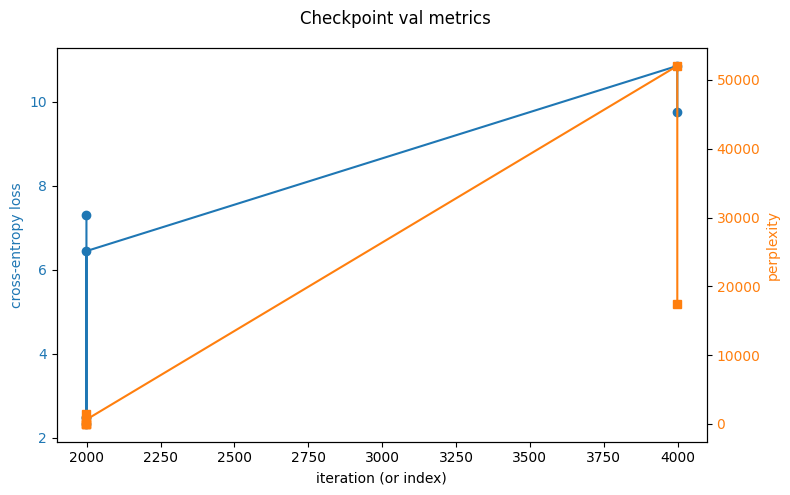

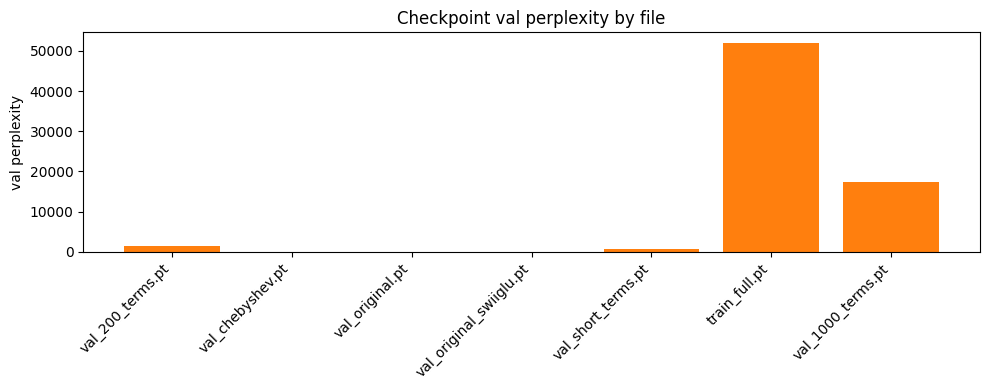

In [7]:
# Show results as a simple markdown table and plots.

if not results:
    print('No results to display.')
else:
    header = (
        f"| # | checkpoint | iteration | {split}_loss | {split}_perplexity |"
        f"|---|-----------|-----------|-----------:|-----------------:|"
    )
    print(header)
    for idx, entry in enumerate(results):
        iteration_val = entry.get('iteration')
        print(
            f"| {idx} | {entry['name']} | {iteration_val if iteration_val is not None else 'n/a'} | "
            f"{entry[f'{split}_loss']:.4f} | {entry[f'{split}_perplexity']:.4f} |"
        )

    plot_metrics(results, split=split)

In [ ]:
# Show results as a simple markdown table and plots.

if not results:
    print('No results to display.')
else:
    header = (
        f"| # | checkpoint | iteration | {split}_loss | {split}_perplexity |"
        f"|---|-----------|-----------|-----------:|-----------------:|"
    )
    print(header)
    for idx, entry in enumerate(results):
        iteration_val = entry.get('iteration')
        print(
            f"| {idx} | {entry['name']} | {iteration_val if iteration_val is not None else 'n/a'} | "
            f"{entry[f'{split}_loss']:.4f} | {entry[f'{split}_perplexity']:.4f} |"
        )

    plot_metrics(results, split=split)

| # | checkpoint | iteration | val_loss | val_perplexity ||---|-----------|-----------|-----------:|-----------------:|
| 0 | best_val.pt | 1999 | 2.9435 | 18.9886 |
| 1 | train_full.pt | 3999 | 8.8150 | 6735.9241 |
| 2 | val.pt | 3999 | 2.6716 | 14.4682 |
| 3 | val_original.pt | 1999 | 6.4321 | 621.5475 |
| 4 | val_short_terms.pt | 1999 | 2.9569 | 19.2442 |